Imanol Mendoza

# Proyecto: Clasificación Bayesiana y Comparación de Modelos

## Objetivo general

El objetivo de este proyecto es construir, ajustar y comparar modelos bayesianos de clasificación binaria utilizando datos reales. Los estudiantes deberán implementar distintos modelos de regresión binaria en NumPyro y evaluar su capacidad predictiva mediante técnicas de validación cruzada.

El proyecto busca integrar:

- modelación probabilística,
- inferencia bayesiana,
- clasificación supervisada,
- métodos MCMC,
- y evaluación predictiva.

---

# Notación

- $y_i \in \{0,1\}$ representa la clase observada.
- $x_i$ es el vector de covariables.
- $\beta$ representa los coeficientes de regresión.
- $\tau$ es el hyperparámetro de regularización.
- $X$ representa la matriz de diseño.
- $p$ es el número de covariables.
- $n$ es el número de observaciones.

---

# 1. Clasificación binaria

Se considera un problema de clasificación binaria donde:

$$
y_i \in \{0,1\}
$$

La probabilidad de pertenecer a la clase positiva depende de un predictor lineal:

$$
\eta_i = x_i^T\beta
$$

y:

$$
y_i \mid x_i,\beta \sim \text{Bernoulli}(\pi_i)
$$

donde $\pi_i$ representa la probabilidad de éxito.

---

# 2. Enfoque Bayesiano

En inferencia bayesiana los parámetros se modelan como variables aleatorias.

El objetivo es aproximar la distribución posterior:

$$
p(\beta,\tau \mid X,y)
$$

utilizando el Teorema de Bayes:

$$
p(\theta \mid y)
\propto
p(y \mid \theta)p(\theta)
$$

---

# 3. Regularización Bayesiana

Los coeficientes utilizan priors Gaussianos:

$$
\beta_j \sim \mathcal{N}(0,\tau^2)
$$

con hyperprior:

$$
\tau \sim \text{HalfNormal}(1)
$$

Esto induce regularización sobre los coeficientes y ayuda a controlar sobreajuste.

---

# 4. Regresión Logística

La regresión logística utiliza la función sigmoide:

$$
\pi_i
=
\frac{1}{1+\exp(-x_i^T\beta)}
$$

por lo que:

$$
y_i
\sim
\text{Bernoulli}(\pi_i)
$$

La función logística transforma el predictor lineal en probabilidades dentro del intervalo $(0,1)$.

---

# 5. Regresión Probit

El modelo Probit utiliza la función de distribución acumulada de una Normal estándar:

$$
\pi_i
=
\Phi(x_i^T\beta)
$$

donde $\Phi$ representa la CDF de una Normal estándar.

Este modelo produce probabilidades similares al modelo logístico, pero con una interpretación basada en variables latentes Gaussianas.

---

# 6. Regresión Complementary Log-Log

El modelo complementary log-log utiliza:

$$
\pi_i
=
1-\exp(-\exp(x_i^T\beta))
$$

Este enlace es asimétrico y suele utilizarse cuando las probabilidades extremas tienen comportamiento no simétrico.

---

# 7. Inferencia mediante MCMC y NUTS

La distribución posterior se aproxima utilizando:

- Hamiltonian Monte Carlo (HMC),
- No-U-Turn Sampler (NUTS).

El algoritmo NUTS permite:

- muestreo eficiente,
- exploración de posteriors de alta dimensión,
- adaptación automática de trayectorias Hamiltonianas.

El resultado final consiste en muestras posteriores de los parámetros.

---

# 8. Validación Cruzada

La comparación entre modelos se realizará mediante validación cruzada.

En cada fold:

1. se ajusta el modelo,
2. se generan muestras posteriores,
3. se evalúa desempeño predictivo.

---

# 9. Métricas de evaluación

Se utilizarán las siguientes métricas:

---

## Negative Log-Likelihood (NLL)

$$
\text{NLL}
=
-\log p(y_{\text{valid}} \mid X_{\text{valid}})
$$

Interpretación:

- menor NLL:
  - mejor calibración probabilística,
  - mejor desempeño predictivo.

---

## Accuracy

La accuracy mide la proporción de clasificaciones correctas:

$$
\text{Accuracy}
=
\frac{1}{n}
\sum_{i=1}^{n}
\mathbb{I}(y_i = \hat y_i)
$$

donde $\hat y_i$ representa la clase predicha.

---

## Area Under the Curve (AUC)

El AUC mide la capacidad del modelo para separar ambas clases.

Interpretación general:

- AUC cercano a 1:
  - excelente discriminación.

- AUC cercano a 0.5:
  - desempeño similar al azar.

---

# 10. Análisis posterior

Después del ajuste del modelo se analizarán:

- distribuciones posteriores de los coeficientes,
- incertidumbre posterior,
- distribuciones posteriores del NLL,
- distribuciones posteriores de accuracy,
- distribuciones posteriores de AUC.

Esto permite cuantificar incertidumbre predictiva y comparar modelos desde una perspectiva completamente bayesiana.

---

# 11. Objetivos específicos del proyecto

Los estudiantes deberán:

1. Seleccionar un conjunto de datos reales de clasificación binaria.
2. Realizar limpieza y preprocesamiento.
3. Construir modelos Logit, Probit y Complementary Log-Log.
4. Ajustar modelos mediante NUTS.
5. Analizar convergencia MCMC.
6. Comparar desempeño predictivo.
7. Evaluar incertidumbre posterior.
8. Interpretar coeficientes y probabilidades.
9. Elaborar conclusiones estadísticas y predictivas.

---

# 12. Entregables sugeridos

El proyecto deberá incluir:

- notebook reproducible,
- explicación teórica,
- análisis exploratorio,
- implementación de modelos,
- métricas de evaluación,
- visualizaciones posteriores,
- interpretación estadística,
- conclusiones.

In [1]:
# Operaciones numéricas con JAX
import jax
import jax.numpy as jnp

# Distribuciones probabilísticas
import numpyro.distributions as dist

# Inferencia bayesiana y likelihood
from numpyro.infer import MCMC, NUTS, log_likelihood

# Generación de llaves aleatorias
import jax.random as random

# Train/test split y cross validation
from sklearn.model_selection import train_test_split, KFold

# Librería principal NumPyro
import numpyro

# Computación numérica
import numpy as np

# Manejo de tablas
import pandas as pd

# Visualización
import matplotlib.pyplot as plt

# Métrica AUC
from sklearn.metrics import roc_auc_score

# Barras de progreso
from tqdm import tqdm


# Número de dispositivos/cadenas paralelas
numpyro.set_host_device_count(3)

# Estilo de gráficas
plt.style.use("ggplot")

# **Conjunto de datos**

En el proyecto pueden usar datos simulados para ilustrar, pero también utilicen datos reales para resolver un problema de aprendizaje no supervisado. Realicen el debido preprocesamiento de datos que han aprendido en sus demás cursos antes de ajustar los modelos: escaladores, métodos de reducción de dimensión con PCA, entre otros.

In [2]:
n = 10000
p = 6


np.random.seed(10)
X = np.random.randn(n, p)
X = np.hstack((np.ones((n,1)), X))  # intercepto

beta_true = np.array([2.0, 4.5, -3.5, 0.0, 1.2, -0.04, 0.0])


mu = jax.nn.sigmoid(X @ beta_true)


y = np.random.binomial(n=1, p=mu)


X = jnp.array(X)
y = jnp.array(y)


X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=18081997)


# **Regresión Logística**

In [3]:
# Modelo bayesiano de regresión logística
def logistic_regression(X, y=None):

    # n: observaciones, p: covariables
    n, p = X.shape

    # Hyperprior para regularización
    tau = numpyro.sample("tau", dist.HalfNormal(1.0))

    # Prior sobre los coeficientes
    Beta = numpyro.sample(
        "beta",
        dist.Normal(0., tau).expand([p]).to_event(1)
    )

    # Predictor lineal
    mu = jnp.matmul(X, Beta)

    # Likelihood Bernoulli
    with numpyro.plate("data", n):

        numpyro.sample(
            "y",
            dist.Bernoulli(logits=mu),
            obs=y
        )

In [4]:
burn_in = 1500
num_samples = 2000
num_chains = 3
chain_method = "parallel"

seed = 18081997

In [5]:
def cv_metrics_model(model, X, y, folds=10, seed=1):

    kf = KFold(n_splits=folds, shuffle=True, random_state=seed)

    fold_nll = []
    fold_acc = []
    fold_auc = []

    progress_bar = tqdm(total=folds, desc="Cross Validation")

    for fold, (train_indx, valid_indx) in enumerate(kf.split(X)):

        X_train, X_valid = X[train_indx], X[valid_indx]
        y_train, y_valid = y[train_indx], y[valid_indx]

        rng_key = random.PRNGKey(seed + fold)

        kernel = NUTS(model)

        mcmc = MCMC(kernel,
                        num_samples=num_samples,
                        num_chains=num_chains,
                        num_warmup=burn_in,
                        chain_method=chain_method,
                        progress_bar=False)

        mcmc.run(rng_key, X_train, y_train)

        posterior_samples = mcmc.get_samples()

        beta = posterior_samples["beta"]

        n_samp = beta.shape[0]

        nll = -log_likelihood(model, posterior_samples, X_valid, y_valid)["y"].mean().item()

        prob_pred = jax.nn.sigmoid(jnp.matmul(beta, X_valid.T))

        y_pred = (prob_pred > 0.5).astype(int)

        acc = (y_valid[None, :] == y_pred).mean().item()

        auc_score = []

        for i in range(n_samp):

            auc_score.append(roc_auc_score(y_valid, prob_pred[i, :]))

        auc_score = jnp.array(auc_score).mean().item()

        fold_nll.append(nll)
        fold_acc.append(acc)
        fold_auc.append(auc_score)

        progress_bar.update(1)
        progress_bar.set_postfix({
            "fold": fold,
            "nll": f"{nll:.4f}",
            "acc": f"{acc:.4f}",
            "auc": f"{auc_score:.4f}"
            })


    progress_bar.close()

    return fold_nll, fold_auc, fold_acc

In [63]:
nnl ,auc, acc = cv_metrics_model(logistic_regression, X_train, y_train)


Cross Validation: 100%|██████████| 10/10 [03:07<00:00, 18.74s/it, fold=9, nll=0.2279, acc=0.9075, auc=0.9674]


In [64]:
print("mean nll:", np.mean(nnl))
print("std nll:", np.std(nnl))
print("------------------------------")

print("mean acc:", np.mean(acc))
print("std acc:", np.std(acc))
print("------------------------------")

print("mean auc:", np.mean(auc))
print("std auc:", np.std(auc))



mean nll: 0.20778781771659852
std nll: 0.02271369060028143
------------------------------
mean acc: 0.9110464096069336
std acc: 0.01119509655875097
------------------------------
mean auc: 0.9718786180019379
std auc: 0.005600153376670823


# **Regresión Probit**

In [65]:
norm = dist.Normal(0.0, 1.0)

def probit_regression(X, y=None):

    n, p = X.shape

    tau = numpyro.sample("tau", dist.HalfNormal(1.0))

    Beta = numpyro.sample("beta", dist.Normal(0., tau).expand([p]).to_event(1))

    mu = norm.cdf(jnp.matmul(X, Beta))

    with numpyro.plate("data", n):

        numpyro.sample("y", dist.Bernoulli(probs=mu), obs=y)

In [66]:
nnl , auc, acc = cv_metrics_model(probit_regression, X_train, y_train)

Cross Validation: 100%|██████████| 10/10 [03:09<00:00, 18.91s/it, fold=9, nll=0.2274, acc=0.9072, auc=0.9674]


In [67]:
print("mean nll:", np.mean(nnl))
print("std nll:", np.std(nnl))
print("------------------------------")

print("mean acc:", np.mean(acc))
print("std acc:", np.std(acc))
print("------------------------------")

print("mean auc:", np.mean(auc))
print("std auc:", np.std(auc))

mean nll: 0.20820285826921464
std nll: 0.022370199993569508
------------------------------
mean acc: 0.9111817717552185
std acc: 0.011068506553988179
------------------------------
mean auc: 0.9718733787536621
std auc: 0.005589723306758281


# **Regresión ClogLog**

In [68]:
def cloglog_regression(X, y=None):

    n, p = X.shape

    tau = numpyro.sample("tau", dist.HalfNormal(1.0))

    Beta = numpyro.sample("beta", dist.Normal(0., tau).expand([p]).to_event(1))

    mu = 1 - jnp.exp(-jnp.exp(jnp.matmul(X, Beta)))


    with numpyro.plate("data", n):

        numpyro.sample("y", dist.Bernoulli(probs=mu), obs=y)

In [69]:
nnl , auc, acc = cv_metrics_model(cloglog_regression, X_train, y_train)

Cross Validation: 100%|██████████| 10/10 [03:36<00:00, 21.61s/it, fold=9, nll=0.2323, acc=0.8922, auc=0.9675]


In [71]:
print("mean nll:", np.mean(nnl))
print("std nll:", np.std(nnl))
print("------------------------------")

print("mean acc:", np.mean(acc))
print("std acc:", np.std(acc))
print("------------------------------")

print("mean auc:", np.mean(auc))
print("std auc:", np.std(auc))

mean nll: 0.21359184235334397
std nll: 0.01982320264656626
------------------------------
mean acc: 0.8959830224514007
std acc: 0.009711020607290993
------------------------------
mean auc: 0.9718617618083953
std auc: 0.005567365186473119


# **Mejor modelo: Logístico**

In [72]:
rng_key = random.PRNGKey(seed)

kernel = NUTS(logistic_regression)

mcmc = MCMC(kernel,
            num_samples=num_samples,
            num_chains=num_chains,
            num_warmup=burn_in,
            chain_method=chain_method,
            progress_bar=False)

mcmc.run(rng_key, X_train, y_train)

In [73]:
mcmc.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
   beta[0]      1.95      0.06      1.95      1.85      2.05   2748.55      1.00
   beta[1]      4.45      0.12      4.44      4.26      4.64   2500.33      1.00
   beta[2]     -3.42      0.09     -3.42     -3.57     -3.27   2488.02      1.00
   beta[3]     -0.02      0.04     -0.02     -0.08      0.06   6056.65      1.00
   beta[4]      1.18      0.05      1.19      1.11      1.27   3768.98      1.00
   beta[5]     -0.02      0.04     -0.02     -0.09      0.05   5474.92      1.00
   beta[6]     -0.03      0.04     -0.03     -0.10      0.04   5555.45      1.00
       tau      2.00      0.38      1.96      1.41      2.61   5669.18      1.00

Number of divergences: 0


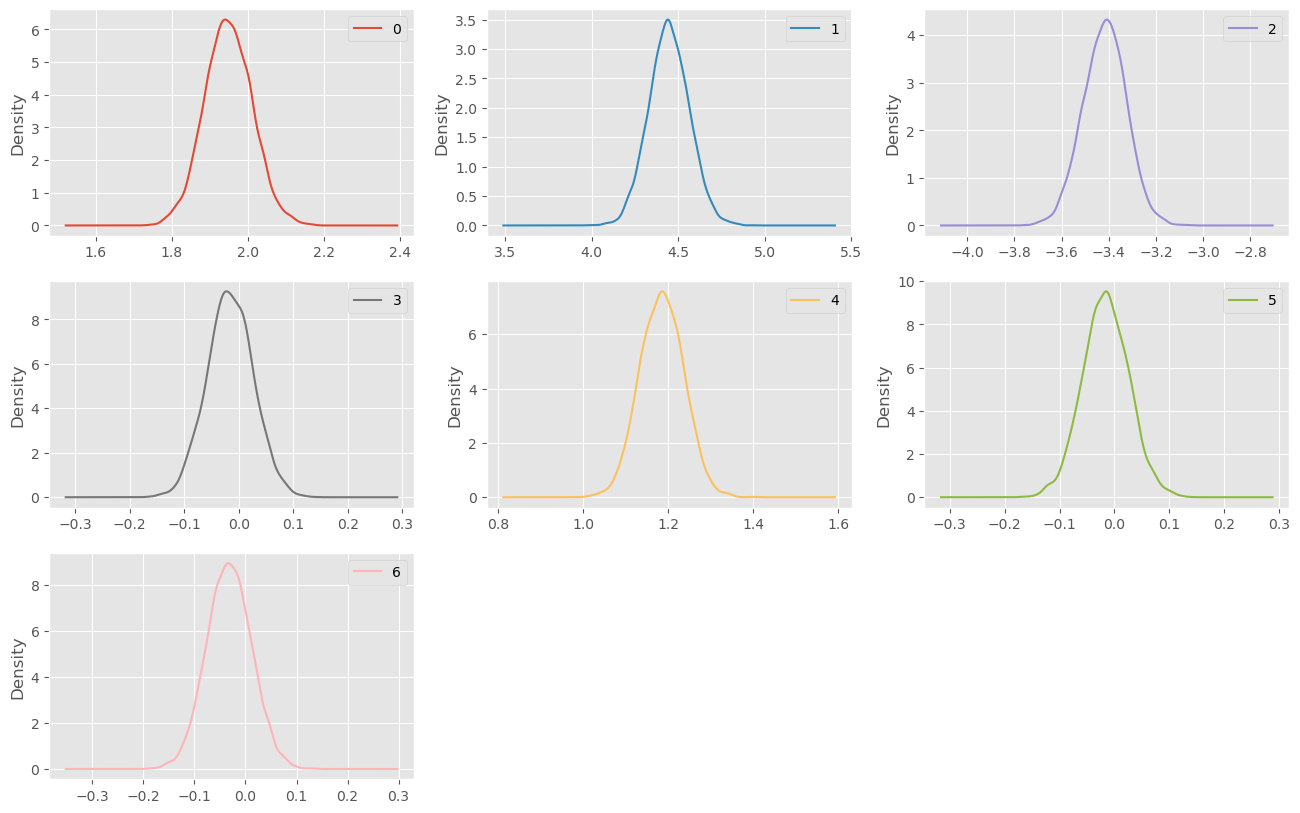

In [74]:
samples = mcmc.get_samples()
pd.DataFrame(samples["beta"]).plot.kde(subplots=True, layout=(3, 3), sharex=False, figsize=(16, 10))
plt.show()

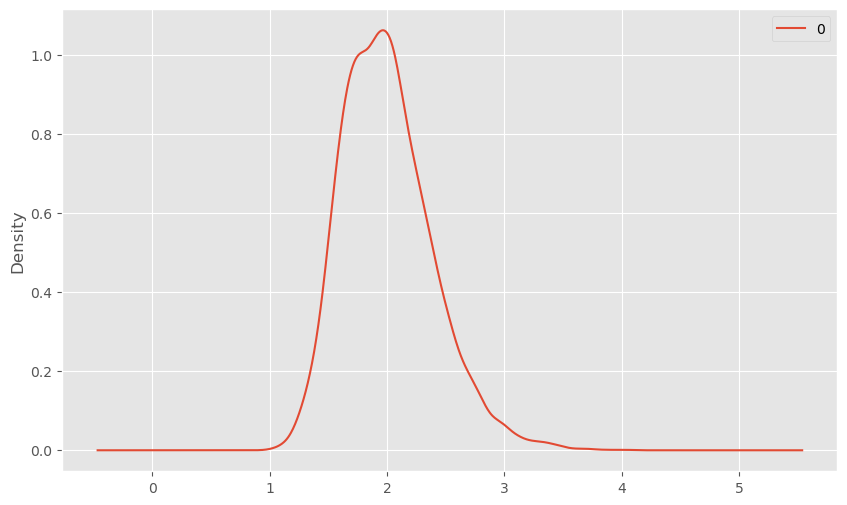

In [37]:
pd.DataFrame(samples["tau"]).plot.kde( figsize=(10, 6))
plt.show()

# **Distribución de algunas métricas**

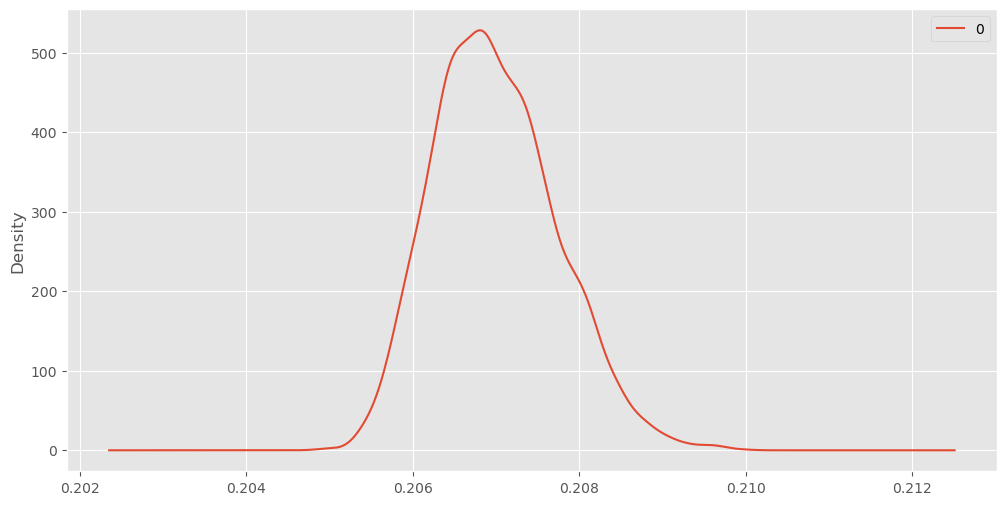

In [38]:
nll_samples = -log_likelihood(logistic_regression, samples, X_val, y_val)["y"].mean(axis=1)
pd.DataFrame(nll_samples).plot.kde(figsize=(12, 6))
plt.show()

[0.906      0.90999997]


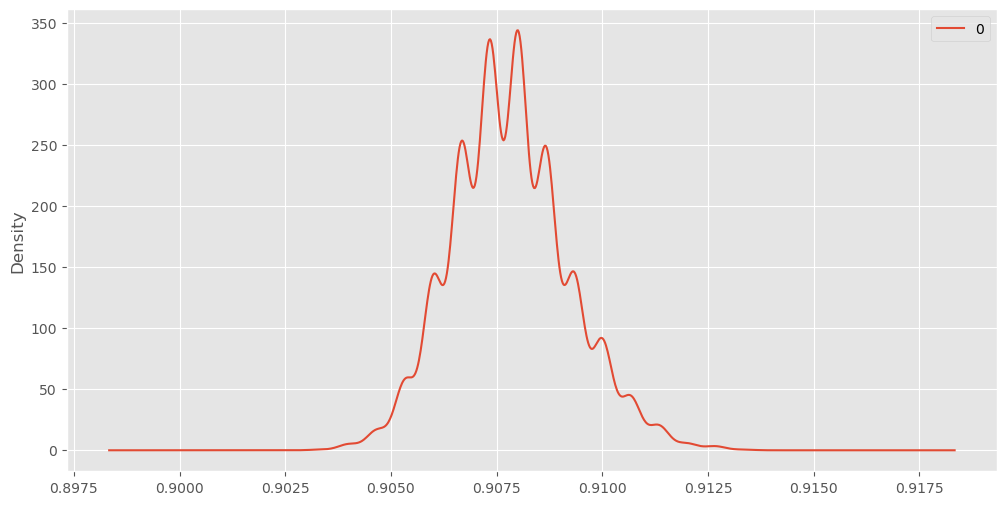

In [78]:
prob_samples = jax.nn.sigmoid(jnp.matmul(samples["beta"], X_val.T))

y_pred_samples = (prob_samples > 0.5).astype(int)


acc_samples = jnp.abs(y_val[None, :]  == y_pred_samples).mean(axis=1)

print(jnp.quantile(acc_samples, jnp.array([0.05, 0.95])))
pd.DataFrame(acc_samples).plot.kde(figsize=(12, 6))
plt.show()


In [80]:
auc_samples = jnp.array([roc_auc_score(y_val, prob_samples[i, :]) for i in range(prob_samples.shape[0])])

[0.97259533 0.97317004]


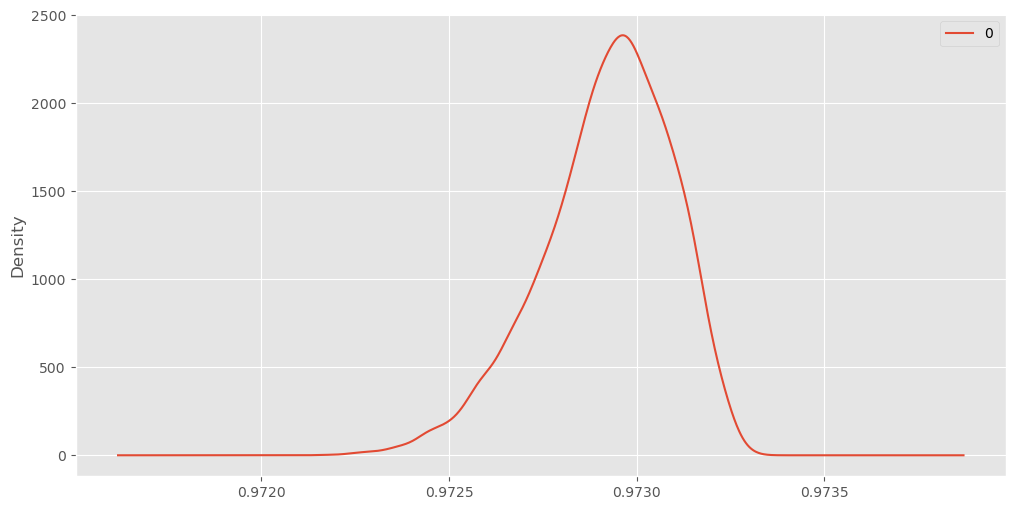

In [81]:
print(jnp.quantile(auc_samples, jnp.array([0.05, 0.95])))
pd.DataFrame(auc_samples).plot.kde(figsize=(12, 6))
plt.show()

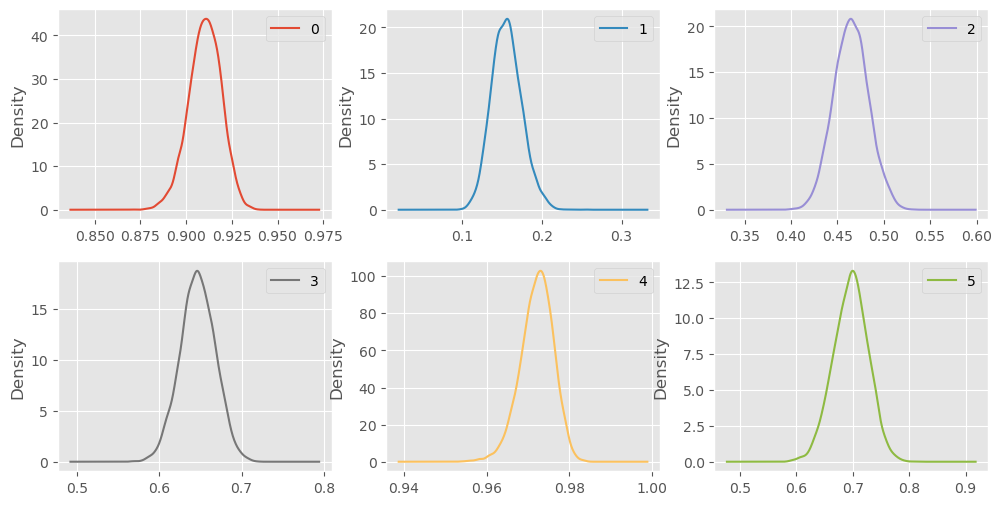

In [85]:
pd.DataFrame(prob_samples[:,:6]).plot.kde(figsize=(12, 6), subplots=True, layout=(2, 3), sharex=False)
plt.show()